# NumPyro walkthrough: Zero- and N-inflated Binomial

This notebook walks through the NumPyro implementation of a ZNI-Binomial
model. We:

1. Define the generative model.
2. Simulate matched data and confirm the fit recovers truth.
3. Progressively misspecify the data and watch the posterior predictive
   degrade.

The companion notebook `02_compare_mcount.ipynb` repeats the same fits with
the R package `mcount::mznib` and compares.

## 1. The model

For a count `y_i ∈ {0, 1, ..., N}`,

```
y_i = 0      with prob  π_0     (structural zero)
y_i = N      with prob  π_N     (structural max)
y_i ~ Bin(N, p)  with prob  1 - π_0 - π_N
```

Priors: `π = (π_0, π_N, π_bin) ~ Dirichlet(1, 1, 1)`, `p ~ Beta(1, 1)`. The
discrete component label is marginalised analytically with `logsumexp`, so
NUTS sees a smooth log-density in `(π, p)`.

In [1]:
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt

from zni_binomial import (
    zni_binomial_model, fit_and_ppc,
    simulate_matched, simulate_overdispersed,
    simulate_mixture, simulate_variable_N,
)

np.set_printoptions(precision=3, suppress=True)

## 2. Simulate matched data and fit

True parameters: `π_0 = 0.15`, `π_N = 0.10`, `p = 0.35`, `N = 20`.

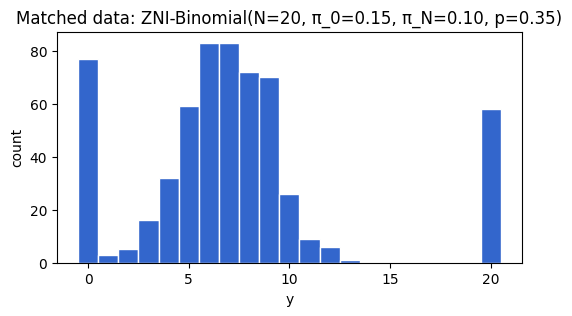

mean y/N: 0.36441666666666667   zeros: 0.12833333333333333   N's: 0.09666666666666666


In [2]:
rng = np.random.default_rng(0)
N = 20
y, _ = simulate_matched(rng, n_obs=600, N=N)

bins = np.arange(0, N + 2) - 0.5
plt.figure(figsize=(6, 3))
plt.hist(y, bins=bins, color="#3366cc", edgecolor="white")
plt.title("Matched data: ZNI-Binomial(N=20, π_0=0.15, π_N=0.10, p=0.35)")
plt.xlabel("y"); plt.ylabel("count")
plt.show()

print("mean y/N:", (y / N).mean(), "  zeros:", (y == 0).mean(),
      "  N's:", (y == N).mean())

In [3]:
samples, ppc = fit_and_ppc(y, N, jax.random.PRNGKey(0))
print("posterior means:")
print(f"  π_0 = {samples['pi'][:,0].mean():.3f}")
print(f"  π_N = {samples['pi'][:,1].mean():.3f}")
print(f"  p   = {samples['p'].mean():.3f}")

/home/user/ai_assisted_research/zero_n_inflated_binomial/zni_binomial.py:115: UserWarning: Sample's batch dimension size 1500 is different from the provided 400 num_samples argument. Defaulting to 1500.
  predictive = Predictive(zni_binomial_model, posterior_samples=samples, num_samples=n_ppc)


posterior means:
  π_0 = 0.130
  π_N = 0.097
  p   = 0.345


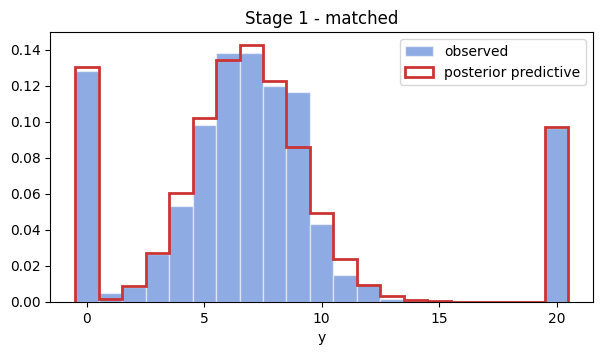

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(y, bins=bins, density=True, alpha=0.55, color="#3366cc",
        edgecolor="white", label="observed")
ax.hist(np.asarray(ppc).reshape(-1), bins=bins, density=True,
        histtype="step", color="#cc3333", linewidth=2.0,
        label="posterior predictive")
ax.legend(); ax.set_xlabel("y"); ax.set_title("Stage 1 - matched")
plt.show()

## 3. Progressively break the model

We feed four datasets of increasing complexity into the same model and
inspect posterior predictive checks.

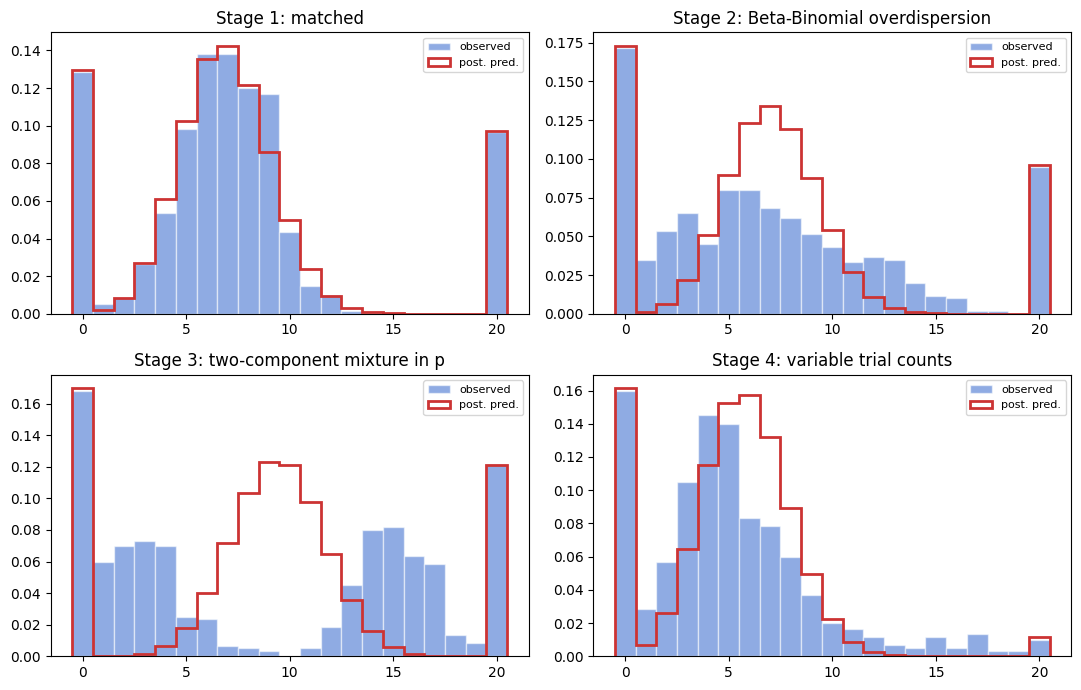

In [5]:
stages = {
    "Stage 1: matched":
        lambda r: simulate_matched(r, 600, N),
    "Stage 2: Beta-Binomial overdispersion":
        lambda r: simulate_overdispersed(r, 600, N),
    "Stage 3: two-component mixture in p":
        lambda r: simulate_mixture(r, 600, N),
    "Stage 4: variable trial counts":
        lambda r: simulate_variable_N(r, 600, N),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
key = jax.random.PRNGKey(0)
for i, (name, gen) in enumerate(stages.items()):
    rng = np.random.default_rng(i)
    yi, _ = gen(rng)
    s, p = fit_and_ppc(yi, N, jax.random.fold_in(key, i))
    ax = axes.flat[i]
    ax.hist(yi, bins=bins, density=True, alpha=0.55, color="#3366cc",
            edgecolor="white", label="observed")
    ax.hist(np.asarray(p).reshape(-1), bins=bins, density=True,
            histtype="step", color="#cc3333", linewidth=2.0,
            label="post. pred.")
    ax.set_title(name); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the panels.** Stage 1 fits perfectly. Stage 2 (Beta-Binomial body)
has heavier tails than any single Binomial; the model mostly absorbs that as
extra zero/N inflation. Stage 3 (bimodal `p` mixture) is the worst — the
model can only put one bump in the body. Stage 4 (varying N_i) collapses
`π_N` to zero because no observation reaches the assumed maximum unless drawn
from the body component.

For a side-by-side animated view, see `zni_binomial_stages.gif`. For the same
data fit with `mcount::mznib` in R, see `02_compare_mcount.ipynb`.